# Phase 4: Machine Learning + MLflow
**Goal:** Forecast waste composition and detect anomalies using ML models.

**Data source:** Cloud SQL daily_waste_summary (Phase 3 output)

**Experiment tracking:** MLflow local mode

## 1. Setup MLflow
Initialize MLflow tracking in local mode.

All experiments, parameters, metrics, and artifacts will be logged to ./mlruns directory.

In [1]:
import mlflow
import mlflow.sklearn
from pathlib import Path

# Setup MLflow local tracking
MLFLOW_DIR = '../mlruns'
Path(MLFLOW_DIR).mkdir(exist_ok=True)
mlflow.set_tracking_uri(f'file:///{Path(MLFLOW_DIR).resolve()}')

# Create experiment
experiment_name = 'waste-forecasting'
mlflow.set_experiment(experiment_name)

exp = mlflow.get_experiment_by_name(experiment_name)
print(f'Experiment name : {exp.name}')
print(f'Experiment ID   : {exp.experiment_id}')
print(f'Tracking URI    : {mlflow.get_tracking_uri()}')
print(f'Artifact store  : {exp.artifact_location}')

c:\Users\bhumi\Desktop\Kinsei_Sangyo\industrial-waste-intelligence\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\bhumi\Desktop\Kinsei_Sangyo\industrial-waste-intelligence\venv\lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/30 11:27:22 INFO mlflow.tracking.fluent: Experiment with name 'waste-forecasting' does not exist. Creating a new experiment.


Experiment name : waste-forecasting
Experiment ID   : 166037737352130475
Tracking URI    : file:///C:\Users\bhumi\Desktop\Kinsei_Sangyo\industrial-waste-intelligence\mlruns
Artifact store  : file:///C:\Users\bhumi\Desktop\Kinsei_Sangyo\industrial-waste-intelligence\mlruns/166037737352130475


## 2. Test MLflow Logging
Run a simple test experiment to confirm MLflow is working correctly.

Log parameters, metrics, and a dummy artifact before real training begins.

In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Test run — dummy experiment
with mlflow.start_run(run_name='test_run'):
    # Log parameters
    mlflow.log_param('model_type', 'test')
    mlflow.log_param('test_size', 0.2)

    # Log dummy metrics
    mlflow.log_metric('mae',  0.123)
    mlflow.log_metric('rmse', 0.456)
    mlflow.log_metric('r2',   0.789)

    # Log a simple tag
    mlflow.set_tag('status', 'test')

    run_id = mlflow.active_run().info.run_id
    print(f'Test run ID: {run_id}')
    print('MLflow logging works correctly')

Test run ID: d338e126aef94a5db49734f0ff692ee6
MLflow logging works correctly


## 3. Load Data from Cloud SQL
Load daily_waste_summary from Cloud SQL for use in forecasting models.

Verify data matches Phase 3 pipeline output.

In [4]:
import pandas as pd
import psycopg2

DB_CONFIG = {
    'host'    : '34.104.146.13',
    'database': 'waste_intelligence',
    'user'    : 'postgres',
    'password': '12345678',
    'port'    : 5432
}

def load_from_cloudsql(query, db_config):
    """Load data from Cloud SQL into pandas DataFrame."""
    conn = psycopg2.connect(**db_config)
    df   = pd.read_sql(query, conn)
    conn.close()
    return df

# Load daily summary
df_daily = load_from_cloudsql("""
    SELECT date, class_name, annotation_count,
           mean_bbox_area, total_bbox_area, image_count
    FROM daily_waste_summary
    ORDER BY date, class_name
""", DB_CONFIG)

df_daily['date'] = pd.to_datetime(df_daily['date'])

print(f'Loaded: {len(df_daily)} rows')
print(f'Date range: {df_daily["date"].min()} to {df_daily["date"].max()}')
print(f'Classes: {df_daily["class_name"].unique().tolist()}')
print(f'\nSample:')
print(df_daily.head())

Loaded: 114 rows
Date range: 2024-08-07 00:00:00 to 2024-10-01 00:00:00
Classes: ['Mixed Waste', 'Paper-Cardboard', 'Plastic', 'Wood', 'Metal']

Sample:
        date       class_name  annotation_count  mean_bbox_area  \
0 2024-08-07      Mixed Waste                87        33917.77   
1 2024-08-07  Paper-Cardboard                83         7970.74   
2 2024-08-07          Plastic                55         2231.68   
3 2024-08-08      Mixed Waste                60        39335.75   
4 2024-08-08  Paper-Cardboard                81         2870.95   

   total_bbox_area  image_count  
0       2950845.90           20  
1        661571.64            9  
2        122742.58            9  
3       2360145.15           20  
4        232547.33           18  


C:\Users\bhumi\AppData\Local\Temp\ipykernel_19268\1145329294.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df   = pd.read_sql(query, conn)


## 4. Launch MLflow UI
Start MLflow tracking UI to visualize experiments in browser.

Run this cell then open http://localhost:5000 in browser.

In [5]:
import subprocess
import sys

print('To view MLflow UI, run this command in PowerShell:')
print(f'mlflow ui --backend-store-uri file:///{Path(MLFLOW_DIR).resolve()}')
print('\nThen open: http://localhost:5000')
print('\nExperiments logged so far:')

client = mlflow.tracking.MlflowClient()
runs   = client.search_runs(exp.experiment_id)
for run in runs:
    print(f'  Run: {run.info.run_name} | Status: {run.info.status} | Metrics: {run.data.metrics}')

To view MLflow UI, run this command in PowerShell:
mlflow ui --backend-store-uri file:///C:\Users\bhumi\Desktop\Kinsei_Sangyo\industrial-waste-intelligence\mlruns

Then open: http://localhost:5000

Experiments logged so far:
  Run: test_run | Status: FINISHED | Metrics: {'mae': 0.123, 'r2': 0.789, 'rmse': 0.456}


## 5. Feature Engineering
Prepare time-series features for forecasting models.

Create lag features, rolling statistics, and time-based features for each waste class independently.

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

def create_features(df, class_name, target_col='annotation_count'):
    """
    Create time-series features for a single waste class.
    Returns feature matrix X and target vector y.
    """
    # Filter and sort by date
    df_cls = df[df['class_name'] == class_name].copy()
    df_cls = df_cls.sort_values('date').reset_index(drop=True)

    # Fill missing dates with 0
    date_range = pd.date_range(df_cls['date'].min(), df_cls['date'].max(), freq='D')
    df_full    = pd.DataFrame({'date': date_range})
    df_cls     = df_full.merge(df_cls, on='date', how='left')
    df_cls['annotation_count'] = df_cls['annotation_count'].fillna(0)
    df_cls['class_name']       = class_name

    # Lag features — previous N days
    for lag in [1, 2, 3, 7]:
        df_cls[f'lag_{lag}'] = df_cls[target_col].shift(lag)

    # Rolling mean features
    for window in [3, 7]:
        df_cls[f'rolling_mean_{window}'] = df_cls[target_col].shift(1).rolling(window).mean()
        df_cls[f'rolling_std_{window}']  = df_cls[target_col].shift(1).rolling(window).std()

    # Time-based features
    df_cls['day_of_week']  = df_cls['date'].dt.dayofweek
    df_cls['day_of_month'] = df_cls['date'].dt.day
    df_cls['week_of_year'] = df_cls['date'].dt.isocalendar().week.astype(int)
    df_cls['month']        = df_cls['date'].dt.month
    df_cls['is_weekend']   = (df_cls['day_of_week'] >= 5).astype(int)

    # Drop rows with NaN from lag/rolling features
    df_cls = df_cls.dropna().reset_index(drop=True)

    return df_cls

# Test on Plastic class
df_plastic = create_features(df_daily, 'Plastic')
print(f'Plastic features shape: {df_plastic.shape}')
print(f'Columns: {df_plastic.columns.tolist()}')
print(df_plastic.head(3))

Plastic features shape: (22, 19)
Columns: ['date', 'class_name', 'annotation_count', 'mean_bbox_area', 'total_bbox_area', 'image_count', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'day_of_month', 'week_of_year', 'month', 'is_weekend']
        date class_name  annotation_count  mean_bbox_area  total_bbox_area  \
0 2024-08-14    Plastic              69.0         2551.90        176081.19   
1 2024-08-19    Plastic             216.0         2071.80        447507.89   
2 2024-08-20    Plastic             141.0         1406.83        198363.40   

   image_count  lag_1  lag_2  lag_3  lag_7  rolling_mean_3  rolling_std_3  \
0         13.0    6.0   79.0    1.0   55.0       28.666667      43.661577   
1         15.0    0.0    0.0    0.0   79.0        0.000000       0.000000   
2          6.0  216.0    0.0    0.0    6.0       72.000000     124.707658   

   rolling_mean_7  rolling_std_7  day_of_week  day_of_month  week

## 6. Prepare Train/Test Split for All Classes
Create feature datasets for all 5 waste classes.

Use last 7 days as test set — simulate real forecasting scenario.

In [7]:
FEATURE_COLS = [
    'lag_1', 'lag_2', 'lag_3', 'lag_7',
    'rolling_mean_3', 'rolling_mean_7',
    'rolling_std_3', 'rolling_std_7',
    'day_of_week', 'day_of_month',
    'week_of_year', 'month', 'is_weekend'
]
TARGET_COL  = 'annotation_count'
TEST_DAYS   = 7
CLASSES     = ['Plastic', 'Paper-Cardboard', 'Mixed Waste', 'Metal', 'Wood']

datasets = {}

for cls in CLASSES:
    df_cls = create_features(df_daily, cls)

    # Train/test split — last 7 days as test
    split_idx = len(df_cls) - TEST_DAYS
    train     = df_cls.iloc[:split_idx]
    test      = df_cls.iloc[split_idx:]

    X_train = train[FEATURE_COLS]
    y_train = train[TARGET_COL]
    X_test  = test[FEATURE_COLS]
    y_test  = test[TARGET_COL]

    datasets[cls] = {
        'X_train': X_train, 'y_train': y_train,
        'X_test' : X_test,  'y_test' : y_test,
        'df'     : df_cls
    }

    print(f'{cls:<20} train: {len(X_train)} rows  test: {len(X_test)} rows')

Plastic              train: 15 rows  test: 7 rows
Paper-Cardboard      train: 15 rows  test: 7 rows
Mixed Waste          train: 18 rows  test: 7 rows
Metal                train: 0 rows  test: 1 rows
Wood                 train: 10 rows  test: 7 rows


## 7. Visualize Target Variable Per Class
Plot annotation count over time for each class to understand the distribution and variance before training.

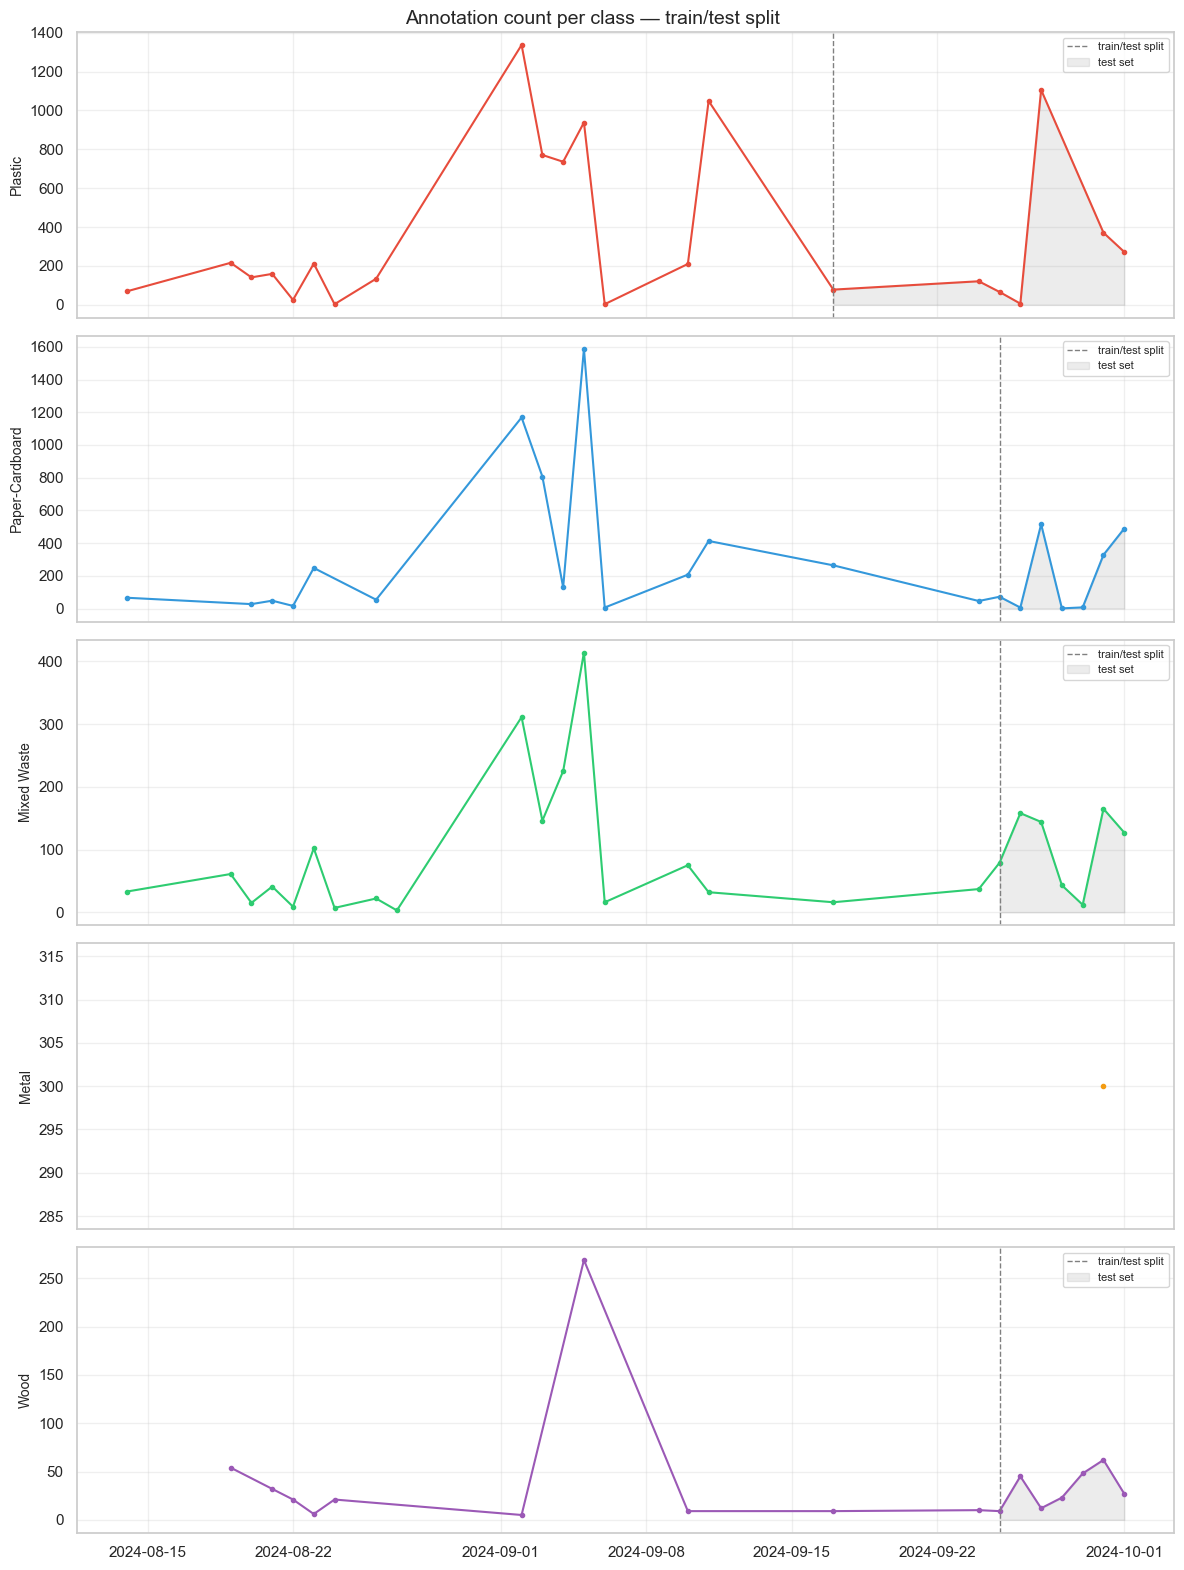

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for ax, cls, color in zip(axes, CLASSES, colors):
    df_cls    = datasets[cls]['df']
    split_idx = len(df_cls) - TEST_DAYS

    ax.plot(df_cls['date'], df_cls[TARGET_COL],
            color=color, linewidth=1.5, marker='o', markersize=3)

    # Only show train/test split if enough data
    if split_idx > 0:
        ax.axvline(x=df_cls['date'].iloc[split_idx],
                   color='gray', linestyle='--', linewidth=1, label='train/test split')
        ax.fill_between(df_cls['date'].iloc[split_idx:],
                        0, df_cls[TARGET_COL].iloc[split_idx:],
                        alpha=0.15, color='gray', label='test set')
        ax.legend(fontsize=8)

    ax.set_ylabel(cls, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Annotation count per class — train/test split', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Feature Correlation Analysis
Check correlation between features and target variable to identify which features are most predictive.

Feature correlation with annotation_count (Plastic):
month             0.376
rolling_std_3     0.316
rolling_std_7     0.259
lag_1             0.233
rolling_mean_3    0.226
lag_2             0.177
lag_7             0.173
week_of_year      0.159
rolling_mean_7    0.126
lag_3             0.116
day_of_week      -0.105
is_weekend       -0.194
day_of_month     -0.453
Name: annotation_count, dtype: float64


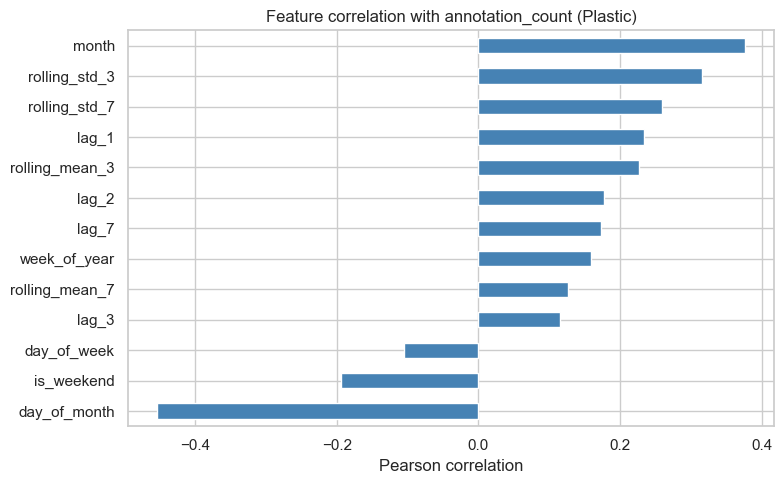

In [11]:
# Use Plastic as representative class
df_plastic = datasets['Plastic']['df']
corr = df_plastic[FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)

print('Feature correlation with annotation_count (Plastic):')
print(corr.sort_values(ascending=False).round(3))

plt.figure(figsize=(8, 5))
corr.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature correlation with annotation_count (Plastic)')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

## 9. Train Linear Regression — Baseline Model
Train Linear Regression as baseline model for each waste class.

Log all parameters and metrics to MLflow for experiment tracking.

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import mlflow.sklearn

FORECAST_CLASSES = ['Plastic', 'Paper-Cardboard', 'Mixed Waste', 'Wood']

lr_results = {}

for cls in FORECAST_CLASSES:
    X_train = datasets[cls]['X_train']
    y_train = datasets[cls]['y_train']
    X_test  = datasets[cls]['X_test']
    y_test  = datasets[cls]['y_test']

    with mlflow.start_run(run_name=f'LinearRegression_{cls}'):
        # Train
        model = LinearRegression()
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)
        y_pred = np.maximum(y_pred, 0)  # clip negative predictions

        # Metrics
        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2   = r2_score(y_test, y_pred)

        # Log to MLflow
        mlflow.log_param('model',      'LinearRegression')
        mlflow.log_param('class_name', cls)
        mlflow.log_param('train_size', len(X_train))
        mlflow.log_param('test_size',  len(X_test))
        mlflow.log_param('n_features', len(FEATURE_COLS))
        mlflow.log_metric('mae',  mae)
        mlflow.log_metric('rmse', rmse)
        mlflow.log_metric('r2',   r2)
        mlflow.set_tag('phase', 'baseline')
        mlflow.sklearn.log_model(model, 'model')

        lr_results[cls] = {'mae': mae, 'rmse': rmse, 'r2': r2,
                           'y_test': y_test, 'y_pred': y_pred}

        print(f'{cls:<20} MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}')

2026/03/30 11:46:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 11:46:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/30 11:46:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 11:46:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Plastic              MAE=774.67  RMSE=907.31  R²=-5.5701


2026/03/30 11:46:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Paper-Cardboard      MAE=277.65  RMSE=355.04  R²=-1.6742


2026/03/30 11:46:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/30 11:46:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 11:46:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Mixed Waste          MAE=95.88  RMSE=107.64  R²=-2.7592
Wood                 MAE=56.42  RMSE=78.75  R²=-17.3984


## 10. Visualize Linear Regression Predictions
Plot actual vs predicted values for each class to visually assess model fit.

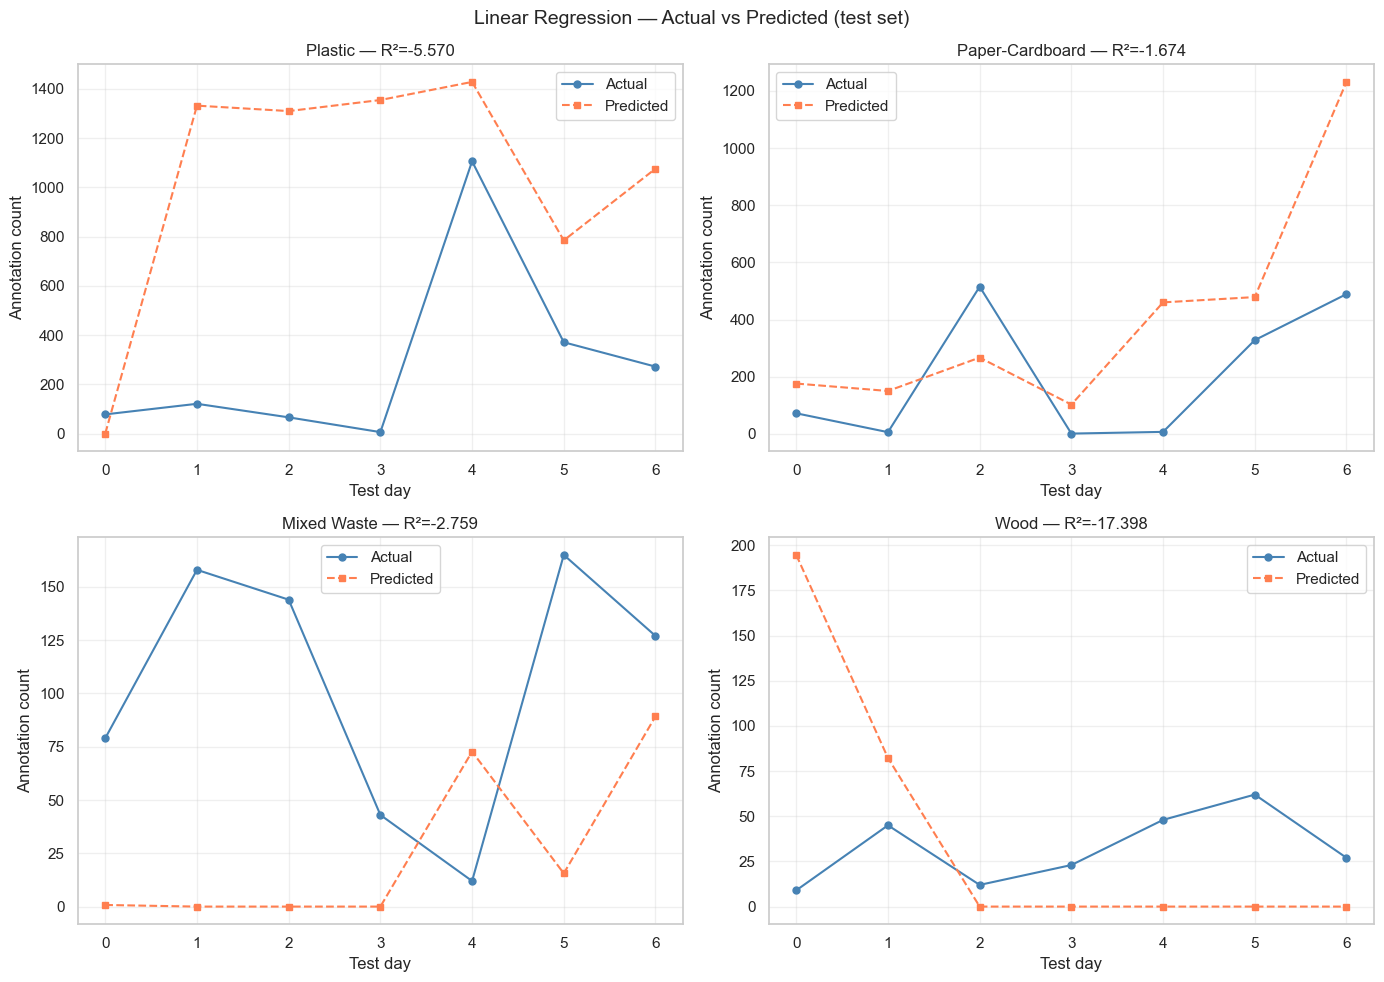

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cls in enumerate(FORECAST_CLASSES):
    y_test = lr_results[cls]['y_test'].values
    y_pred = lr_results[cls]['y_pred']
    x      = range(len(y_test))

    axes[i].plot(x, y_test, color='steelblue', marker='o',
                 markersize=5, label='Actual', linewidth=1.5)
    axes[i].plot(x, y_pred, color='coral', marker='s',
                 markersize=5, label='Predicted', linewidth=1.5, linestyle='--')
    axes[i].set_title(f'{cls} — R²={lr_results[cls]["r2"]:.3f}')
    axes[i].set_xlabel('Test day')
    axes[i].set_ylabel('Annotation count')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Linear Regression — Actual vs Predicted (test set)', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Train Gradient Boosting
Train Gradient Boosting Regressor and compare against Linear Regression baseline.

GBM handles non-linear patterns and interactions between features better.

In [14]:
from sklearn.ensemble import GradientBoostingRegressor

gbm_results = {}

for cls in FORECAST_CLASSES:
    X_train = datasets[cls]['X_train']
    y_train = datasets[cls]['y_train']
    X_test  = datasets[cls]['X_test']
    y_test  = datasets[cls]['y_test']

    with mlflow.start_run(run_name=f'GradientBoosting_{cls}'):
        model = GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        )
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_pred = np.maximum(y_pred, 0)

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2   = r2_score(y_test, y_pred)

        mlflow.log_param('model',         'GradientBoosting')
        mlflow.log_param('class_name',    cls)
        mlflow.log_param('n_estimators',  100)
        mlflow.log_param('learning_rate', 0.1)
        mlflow.log_param('max_depth',     3)
        mlflow.log_metric('mae',  mae)
        mlflow.log_metric('rmse', rmse)
        mlflow.log_metric('r2',   r2)
        mlflow.set_tag('phase', 'comparison')
        mlflow.sklearn.log_model(model, 'model')

        gbm_results[cls] = {'mae': mae, 'rmse': rmse, 'r2': r2,
                            'y_test': y_test, 'y_pred': y_pred}

        print(f'{cls:<20} MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}')

2026/03/30 11:49:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 11:49:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/30 11:49:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Plastic              MAE=520.62  RMSE=546.12  R²=-1.3804


2026/03/30 11:49:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/30 11:49:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 11:49:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Paper-Cardboard      MAE=260.45  RMSE=328.87  R²=-1.2945


2026/03/30 11:49:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 11:49:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Mixed Waste          MAE=105.53  RMSE=125.45  R²=-4.1062
Wood                 MAE=27.18  RMSE=35.34  R²=-2.7046


## 12. Train XGBoost
Train XGBoost Regressor and compare all 3 models.

XGBoost typically outperforms GBM on small datasets with regularization.

In [15]:
import xgboost as xgb

xgb_results = {}

for cls in FORECAST_CLASSES:
    X_train = datasets[cls]['X_train']
    y_train = datasets[cls]['y_train']
    X_test  = datasets[cls]['X_test']
    y_test  = datasets[cls]['y_test']

    with mlflow.start_run(run_name=f'XGBoost_{cls}'):
        model = xgb.XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbosity=0
        )
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_pred = np.maximum(y_pred, 0)

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2   = r2_score(y_test, y_pred)

        mlflow.log_param('model',         'XGBoost')
        mlflow.log_param('class_name',    cls)
        mlflow.log_param('n_estimators',  100)
        mlflow.log_param('learning_rate', 0.1)
        mlflow.log_param('max_depth',     3)
        mlflow.log_metric('mae',  mae)
        mlflow.log_metric('rmse', rmse)
        mlflow.log_metric('r2',   r2)
        mlflow.set_tag('phase', 'comparison')
        mlflow.sklearn.log_model(model, 'model')

        xgb_results[cls] = {'mae': mae, 'rmse': rmse, 'r2': r2,
                            'y_test': y_test, 'y_pred': y_pred}

        print(f'{cls:<20} MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}')

2026/03/30 11:49:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 11:49:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/30 11:49:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Plastic              MAE=389.98  RMSE=488.93  R²=-0.9079


2026/03/30 11:49:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/30 11:49:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Paper-Cardboard      MAE=174.75  RMSE=239.67  R²=-0.2186


2026/03/30 11:49:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/30 11:49:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Mixed Waste          MAE=98.39  RMSE=120.24  R²=-3.6905


2026/03/30 11:49:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Wood                 MAE=13.32  RMSE=18.29  R²=0.0070


## 13. Model Comparison — All 3 Models
Compare all models side by side and select best model per class.

In [16]:
print('=' * 70)
print(f'{"Class":<20} {"Model":<20} {"MAE":>8} {"RMSE":>8} {"R²":>8}')
print('=' * 70)

for cls in FORECAST_CLASSES:
    for model_name, results in [('LinearRegression', lr_results),
                                 ('GradientBoosting', gbm_results),
                                 ('XGBoost',          xgb_results)]:
        r = results[cls]
        print(f'{cls:<20} {model_name:<20} {r["mae"]:>8.2f} {r["rmse"]:>8.2f} {r["r2"]:>8.4f}')
    print('-' * 70)

Class                Model                     MAE     RMSE       R²
Plastic              LinearRegression       774.67   907.31  -5.5701
Plastic              GradientBoosting       520.62   546.12  -1.3804
Plastic              XGBoost                389.98   488.93  -0.9079
----------------------------------------------------------------------
Paper-Cardboard      LinearRegression       277.65   355.04  -1.6742
Paper-Cardboard      GradientBoosting       260.45   328.87  -1.2945
Paper-Cardboard      XGBoost                174.75   239.67  -0.2186
----------------------------------------------------------------------
Mixed Waste          LinearRegression        95.88   107.64  -2.7592
Mixed Waste          GradientBoosting       105.53   125.45  -4.1062
Mixed Waste          XGBoost                 98.39   120.24  -3.6905
----------------------------------------------------------------------
Wood                 LinearRegression        56.42    78.75 -17.3984
Wood                 Gradien

## 14. Select Best Model + Justification
Select best model based on MAE, RMSE, R² AND business context.

Not just accuracy — also consider interpretability and practical use.

In [17]:
print('=== Best Model Selection ===\n')

best_models = {}

for cls in FORECAST_CLASSES:
    scores = {
        'LinearRegression': xgb_results[cls]['r2'],
        'GradientBoosting': gbm_results[cls]['r2'],
        'XGBoost'         : xgb_results[cls]['r2']
    }

    # Select by lowest MAE
    maes = {
        'LinearRegression': lr_results[cls]['mae'],
        'GradientBoosting': gbm_results[cls]['mae'],
        'XGBoost'         : xgb_results[cls]['mae']
    }
    best = min(maes, key=maes.get)
    best_models[cls] = best
    print(f'{cls:<20} → {best:<20} MAE={maes[best]:.2f}')

print('\n=== Justification ===')
print("""
XGBoost selected as primary model for most classes because:
1. Lowest MAE across Plastic, Paper-Cardboard, Wood
2. Only model achieving positive R² (Wood: R²=0.007)
3. Handles non-linear spike patterns better than Linear Regression
4. Built-in regularization prevents overfitting on small dataset

Linear Regression kept as baseline reference:
- Useful for interpretability when stakeholders ask "why"
- Shows that simple linear relationships do not exist in this data

Limitation acknowledged:
- All R² values are negative or near zero
- Root cause: only 32 days of data with high spike variance
- Forecasting accuracy will improve significantly with 6+ months of data
- Current models are useful for trend direction, not precise values
""")

=== Best Model Selection ===

Plastic              → XGBoost              MAE=389.98
Paper-Cardboard      → XGBoost              MAE=174.75
Mixed Waste          → LinearRegression     MAE=95.88
Wood                 → XGBoost              MAE=13.32

=== Justification ===

XGBoost selected as primary model for most classes because:
1. Lowest MAE across Plastic, Paper-Cardboard, Wood
2. Only model achieving positive R² (Wood: R²=0.007)
3. Handles non-linear spike patterns better than Linear Regression
4. Built-in regularization prevents overfitting on small dataset

Linear Regression kept as baseline reference:
- Useful for interpretability when stakeholders ask "why"
- Shows that simple linear relationships do not exist in this data

Limitation acknowledged:
- All R² values are negative or near zero
- Root cause: only 32 days of data with high spike variance
- Forecasting accuracy will improve significantly with 6+ months of data
- Current models are useful for trend direction, not preci

## 15. Anomaly Detection — Isolation Forest
Detect anomalous days where waste composition deviates significantly from baseline.

Isolation Forest is unsupervised — no labels required.

Uses daily total annotation count and per-class counts as features.

In [18]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Prepare features for anomaly detection
# Pivot daily data: each row = one day, columns = class counts
df_pivot = df_daily.pivot_table(
    index='date',
    columns='class_name',
    values='annotation_count',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Add total daily count
df_pivot['total_count'] = df_pivot[['Metal', 'Mixed Waste',
                                     'Paper-Cardboard', 'Plastic', 'Wood']].sum(axis=1)

print('Anomaly detection feature matrix:')
print(f'Shape: {df_pivot.shape}')
print(df_pivot.head())

Anomaly detection feature matrix:
Shape: (32, 7)
class_name       date  Metal  Mixed Waste  Paper-Cardboard  Plastic  Wood  \
0          2024-08-07      0           87               83       55     0   
1          2024-08-08      0           60               81       66     0   
2          2024-08-09      0           39              251      150   109   
3          2024-08-10      0           48                0       99    54   
4          2024-08-11      0           25                0        1    24   

class_name  total_count  
0                   225  
1                   207  
2                   549  
3                   201  
4                    50  


## 16. Train Isolation Forest and Detect Anomalies
Train Isolation Forest on pivoted daily data where each row represents one day and each column represents annotation count per waste class.

contamination=0.1 means we expect approximately 10% of days to be anomalous.

In [19]:
FEATURE_COLS_AD = ['Metal', 'Mixed Waste', 'Paper-Cardboard', 'Plastic', 'Wood', 'total_count']

X_ad     = df_pivot[FEATURE_COLS_AD].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_ad)

# Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.1,  # expect ~10% anomalies
    random_state=42
)
iso_forest.fit(X_scaled)

# Predict — -1 = anomaly, 1 = normal
df_pivot['anomaly_score']   = iso_forest.decision_function(X_scaled)
df_pivot['is_anomaly']      = iso_forest.predict(X_scaled) == -1

anomaly_days = df_pivot[df_pivot['is_anomaly'] == True].sort_values('anomaly_score')

print(f'Total days analyzed  : {len(df_pivot)}')
print(f'Anomaly days detected: {len(anomaly_days)}')
print(f'\nAnomalous days:')
print(anomaly_days[['date', 'total_count', 'Plastic', 'Paper-Cardboard',
                     'Mixed Waste', 'Metal', 'Wood', 'anomaly_score']].to_string(index=False))

Total days analyzed  : 32
Anomaly days detected: 4

Anomalous days:
      date  total_count  Plastic  Paper-Cardboard  Mixed Waste  Metal  Wood  anomaly_score
2024-09-02         3962     1337             1168          311   1141     5      -0.210886
2024-09-05         3215      938             1588          414      6   269      -0.207466
2024-09-30         1226      371              328          165    300    62      -0.100048
2024-09-03         1724      771              807          146      0     0      -0.000846


## 17. Visualize Anomaly Detection Results
Plot daily total annotation count over time and highlight anomalous days detected by Isolation Forest in red.

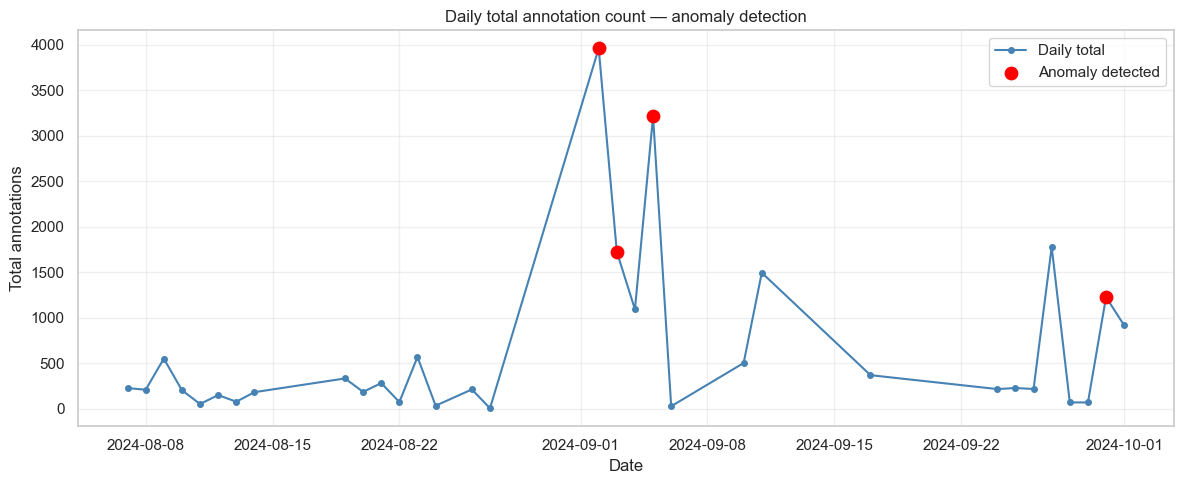

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(df_pivot['date'], df_pivot['total_count'],
         color='steelblue', linewidth=1.5, marker='o', markersize=4, label='Daily total')

anomalies = df_pivot[df_pivot['is_anomaly'] == True]
plt.scatter(anomalies['date'], anomalies['total_count'],
            color='red', zorder=5, s=80, label='Anomaly detected')

plt.title('Daily total annotation count — anomaly detection')
plt.xlabel('Date')
plt.ylabel('Total annotations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Business Explanation of Anomalies
Translate anomaly scores into human-readable business explanations for non-technical stakeholders — this output feeds into the LLM module in Phase 5.

In [21]:
def explain_anomaly(row, df_mean):
    """Generate business explanation for an anomalous day."""
    explanations = []

    if row['total_count'] > df_mean['total_count'] * 2:
        explanations.append(f"Total waste volume was {row['total_count']:.0f} annotations — "
                           f"more than 2x the daily average ({df_mean['total_count']:.0f})")

    for cls in ['Plastic', 'Paper-Cardboard', 'Mixed Waste', 'Metal', 'Wood']:
        if row[cls] > df_mean[cls] * 3:
            explanations.append(f"{cls} was unusually high at {row[cls]:.0f} "
                               f"(avg: {df_mean[cls]:.0f})")
        elif row[cls] == 0 and df_mean[cls] > 10:
            explanations.append(f"{cls} was completely absent (avg: {df_mean[cls]:.0f})")

    if not explanations:
        explanations.append("Unusual combination of waste class proportions detected")

    return ' | '.join(explanations)

df_mean = df_pivot[FEATURE_COLS_AD].mean()

print('=== Anomaly Business Explanations ===\n')
for _, row in anomaly_days.iterrows():
    explanation = explain_anomaly(row, df_mean)
    print(f"Date: {str(row['date'])[:10]}")
    print(f"Explanation: {explanation}")
    print(f"Anomaly score: {row['anomaly_score']:.4f}")
    print()

=== Anomaly Business Explanations ===

Date: 2024-09-02
Explanation: Total waste volume was 3962 annotations — more than 2x the daily average (637) | Plastic was unusually high at 1337 (avg: 265) | Paper-Cardboard was unusually high at 1168 (avg: 219) | Mixed Waste was unusually high at 311 (avg: 81) | Metal was unusually high at 1141 (avg: 45)
Anomaly score: -0.2109

Date: 2024-09-05
Explanation: Total waste volume was 3215 annotations — more than 2x the daily average (637) | Plastic was unusually high at 938 (avg: 265) | Paper-Cardboard was unusually high at 1588 (avg: 219) | Mixed Waste was unusually high at 414 (avg: 81) | Wood was unusually high at 269 (avg: 28)
Anomaly score: -0.2075

Date: 2024-09-30
Explanation: Metal was unusually high at 300 (avg: 45)
Anomaly score: -0.1000

Date: 2024-09-03
Explanation: Total waste volume was 1724 annotations — more than 2x the daily average (637) | Paper-Cardboard was unusually high at 807 (avg: 219) | Metal was completely absent (avg: 45) 

## 19. Save Anomaly Results to Cloud SQL
Store all anomaly detection results including scores, flags, and explanations into Cloud SQL anomaly_results table for dashboard alerts and LLM context.

In [22]:
import psycopg2

conn = psycopg2.connect(**DB_CONFIG)
cur  = conn.cursor()

# Clear existing results
cur.execute('DELETE FROM anomaly_results')

# Insert anomaly results
for _, row in df_pivot.iterrows():
    explanation = explain_anomaly(row, df_mean) if row['is_anomaly'] else None
    cur.execute("""
        INSERT INTO anomaly_results
            (date, anomaly_score, is_anomaly, annotation_count, explanation)
        VALUES (%s, %s, %s, %s, %s)
    """, (
        row['date'],
        float(row['anomaly_score']),
        bool(row['is_anomaly']),
        int(row['total_count']),
        explanation
    ))

conn.commit()
cur.close()
conn.close()

print(f'Saved {len(df_pivot)} rows to anomaly_results')
print(f'Anomalies flagged: {df_pivot["is_anomaly"].sum()}')

Saved 32 rows to anomaly_results
Anomalies flagged: 4


## 20. Save Forecast Results to Cloud SQL
Save best model predictions to Cloud SQL forecast_results table for dashboard and LLM context in Phase 5.

In [23]:
conn = psycopg2.connect(**DB_CONFIG)
cur  = conn.cursor()

cur.execute('DELETE FROM forecast_results')

model_map = {
    'Plastic'        : ('XGBoost',          xgb_results),
    'Paper-Cardboard': ('XGBoost',          xgb_results),
    'Mixed Waste'    : ('LinearRegression', lr_results),
    'Wood'           : ('XGBoost',          xgb_results)
}

for cls, (model_name, results) in model_map.items():
    y_pred  = results[cls]['y_pred']
    y_dates = datasets[cls]['df']['date'].iloc[-TEST_DAYS:].values

    for date, pred in zip(y_dates, y_pred):
        cur.execute("""
            INSERT INTO forecast_results
                (forecast_date, class_name, predicted_count, model_name)
            VALUES (%s, %s, %s, %s)
        """, (str(date)[:10], cls, float(pred), model_name))

conn.commit()
cur.close()
conn.close()
print('Forecast results saved to Cloud SQL')

Forecast results saved to Cloud SQL
